## Setup and preprocessing — fresh raw load, same encoding as combined-DAG notebook

In [2]:
import pandas as pd
import numpy as np
import os
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from dowhy import CausalModel
from econml.dml import CausalForestDML

OUTPUT_DIR = r"C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\BBB"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DATA_PATH = r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\BBB.csv"
df = pd.read_csv(DATA_PATH)

df_sel = df.copy()

df_sel['imd_band'] = df_sel['imd_band'].replace('10-20', '10-20%')
imd_mode = df_sel['imd_band'].mode()[0]
df_sel['imd_band'] = df_sel['imd_band'].fillna(imd_mode)

final_result_map = {'Withdrawn': 0, 'Fail': 1, 'Pass': 2, 'Distinction': 3}
df_sel['final_result'] = df_sel['final_result'].map(final_result_map)

highest_education_map = {
    'No Formal quals': 0, 'Lower Than A Level': 1, 'A Level or Equivalent': 2,
    'HE Qualification': 3, 'Post Graduate Qualification': 4
}
df_sel['highest_education'] = df_sel['highest_education'].map(highest_education_map)

imd_band_map = {
    '0-10%': 0, '10-20%': 1, '20-30%': 2, '30-40%': 3, '40-50%': 4,
    '50-60%': 5, '60-70%': 6, '70-80%': 7, '80-90%': 8, '90-100%': 9
}
df_sel['imd_band'] = df_sel['imd_band'].map(imd_band_map)

age_band_map = {'0-35': 0, '35-55': 1, '55<=': 2}
df_sel['age_band'] = df_sel['age_band'].map(age_band_map)

df_sel['gender'] = df_sel['gender'].map({'F': 0, 'M': 1})
df_sel['disability'] = df_sel['disability'].map({'N': 0, 'Y': 1})

le = LabelEncoder()
df_sel['region'] = le.fit_transform(df_sel['region'])

# Assessment scores — fill + quartile bin
assessment_cols = [c for c in df_sel.columns if c.startswith('ass_') and c.endswith('_score')]
for col in assessment_cols:
    df_sel[col] = df_sel[col].fillna(-1)
    try:
        df_sel[col] = pd.qcut(df_sel[col], q=4, labels=False, duplicates='drop')
    except ValueError:
        pass

# Individual click columns — fill, kept RAW here (not yet binned) for DAG3's fresh pull
click_cols = [c for c in df_sel.columns if c.startswith('clicks_')]
for col in click_cols:
    df_sel[col] = df_sel[col].fillna(0)

print(df_sel.shape)
df_sel.isna().sum().sum()

(5617, 46)


np.int64(30147)

## DAG1 — Demographics vs final_result — build graph, derive adjustment sets, run ATE

In [5]:
dag1_edges = [
    ('gender', 'age_band'),
    ('highest_education', 'region'),
    ('imd_band', 'region'),
    ('age_band', 'region'),
    ('region', 'final_result'),
    ('highest_education', 'imd_band'),
    ('age_band', 'highest_education'),
    ('disability', 'highest_education'),
    ('highest_education', 'final_result'),
    ('imd_band', 'final_result'),
    ('age_band', 'final_result'),
]
# Undirected pairs — not part of directed adjustment-set derivation
dag1_undirected = [('disability', 'num_of_prev_attempts'), ('num_of_prev_attempts', 'studied_credits')]

G1 = nx.DiGraph()
G1.add_edges_from(dag1_edges)

dag1_treatments = [n for n in G1.nodes() if n != 'final_result' and nx.has_path(G1, n, 'final_result')]
print("DAG1 treatments:", dag1_treatments)

dag1_adjustment_sets = {t: list(G1.predecessors(t)) for t in dag1_treatments}
for t, adj in dag1_adjustment_sets.items():
    print(t, "->", adj)

DAG1 treatments: ['gender', 'age_band', 'highest_education', 'region', 'imd_band', 'disability']
gender -> []
age_band -> ['gender']
highest_education -> ['age_band', 'disability']
region -> ['highest_education', 'imd_band', 'age_band']
imd_band -> ['highest_education']
disability -> []


## DAG1 — ATE loop with refutation

In [8]:
dag1_results = []
dag1_refutation = []

for treatment in dag1_treatments:
    common_causes = dag1_adjustment_sets[treatment]

    model = CausalModel(
        data=df_sel,
        treatment=treatment,
        outcome='final_result',
        common_causes=common_causes if len(common_causes) > 0 else None
    )
    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.linear_regression",
        confidence_intervals=True
    )

    ate = estimate.value
    ci = estimate.get_confidence_intervals()
    ci_low, ci_high = ci[0][0], ci[0][1]
    significant = not (ci_low <= 0 <= ci_high)

    dag1_results.append({
        'DAG': 1, 'treatment': treatment, 'adjustment_set': common_causes,
        'ATE': ate, 'CI_lower': ci_low, 'CI_upper': ci_high, 'significant': significant
    })

    placebo_refute = model.refute_estimate(identified_estimand, estimate,
                                            method_name="placebo_treatment_refuter", placebo_type="permute")
    random_cause_refute = model.refute_estimate(identified_estimand, estimate,
                                                 method_name="random_common_cause")

    dag1_refutation.append({
        'treatment': treatment, 'original_ATE': ate,
        'placebo_new_effect': placebo_refute.new_effect,
        'random_cause_diff': abs(random_cause_refute.new_effect - ate)
    })

    print(f"{treatment}: ATE={ate:.3f}, CI=[{ci_low:.3f}, {ci_high:.3f}], significant={significant}")

dag1_results_df = pd.DataFrame(dag1_results)
dag1_refutation_df = pd.DataFrame(dag1_refutation)
dag1_results_df

gender: ATE=0.005, CI=[-0.076, 0.085], significant=False
age_band: ATE=0.180, CI=[0.125, 0.234], significant=True
highest_education: ATE=0.251, CI=[0.215, 0.287], significant=True
region: ATE=0.012, CI=[0.006, 0.019], significant=True
imd_band: ATE=0.044, CI=[0.035, 0.053], significant=True
disability: ATE=-0.186, CI=[-0.271, -0.100], significant=True


,DAG,treatment,adjustment_set,ATE,CI_lower,CI_upper,significant
0,1,gender,[],0.004574,-0.075583,0.084732,False
1,1,age_band,[gender],0.179709,0.125483,0.233936,True
2,1,highest_education,"[age_band, disability]",0.251264,0.215374,0.287155,True
3,1,region,"[highest_education, imd_band, age_band]",0.012200,0.005705,0.018695,True
4,1,imd_band,[highest_education],0.044354,0.035359,0.053349,True
5,1,disability,[],-0.185792,-0.271445,-0.100140,True


## DAG1 — refutation check

In [11]:
dag1_refutation_df

,treatment,original_ATE,placebo_new_effect,random_cause_diff
0,gender,0.004574,0.004048,0.000026
1,age_band,0.179709,0.000140,0.000040
2,highest_education,0.251264,0.003051,0.000032
3,region,0.012200,-0.000084,0.000004
4,imd_band,0.044354,-0.000174,0.000003
5,disability,-0.185792,0.006773,0.000104


## DAG2 — Assessments vs final_result — build graph, derive adjustment sets, run ATE + refutation

In [14]:
dag2_edges = [
    ('ass_1_score', 'ass_2_score'), ('ass_1_score', 'ass_3_score'), ('ass_1_score', 'ass_4_score'),
    ('ass_1_score', 'ass_5_score'), ('ass_1_score', 'ass_7_score'), ('ass_1_score', 'ass_8_score'),
    ('ass_1_score', 'ass_9_score'), ('ass_1_score', 'ass_10_score'), ('ass_1_score', 'final_result'),
    ('ass_2_score', 'ass_3_score'), ('ass_2_score', 'ass_4_score'), ('ass_2_score', 'ass_5_score'),
    ('ass_2_score', 'ass_7_score'), ('ass_2_score', 'ass_8_score'), ('ass_2_score', 'final_result'),
    ('ass_3_score', 'ass_4_score'), ('ass_3_score', 'ass_5_score'), ('ass_3_score', 'ass_6_score'),
    ('ass_3_score', 'ass_7_score'), ('ass_3_score', 'ass_8_score'), ('ass_3_score', 'ass_9_score'),
    ('ass_3_score', 'final_result'),
    ('ass_4_score', 'ass_5_score'), ('ass_4_score', 'ass_6_score'), ('ass_4_score', 'ass_9_score'),
    ('ass_4_score', 'ass_10_score'), ('ass_4_score', 'final_result'),
    ('ass_5_score', 'ass_6_score'), ('ass_5_score', 'ass_10_score'), ('ass_5_score', 'final_result'),
    ('ass_6_score', 'ass_10_score'), ('ass_6_score', 'final_result'),
    ('ass_7_score', 'ass_8_score'), ('ass_7_score', 'ass_9_score'), ('ass_7_score', 'final_result'),
    ('ass_8_score', 'ass_9_score'), ('ass_8_score', 'ass_10_score'), ('ass_8_score', 'final_result'),
    ('ass_9_score', 'ass_10_score'), ('ass_9_score', 'final_result'),
]

G2 = nx.DiGraph()
G2.add_edges_from(dag2_edges)

dag2_treatments = [n for n in G2.nodes() if n != 'final_result' and nx.has_path(G2, n, 'final_result')]
print("DAG2 treatments:", dag2_treatments)

dag2_adjustment_sets = {t: list(G2.predecessors(t)) for t in dag2_treatments}
for t, adj in dag2_adjustment_sets.items():
    print(t, "->", adj)

DAG2 treatments: ['ass_1_score', 'ass_2_score', 'ass_3_score', 'ass_4_score', 'ass_5_score', 'ass_7_score', 'ass_8_score', 'ass_9_score', 'ass_6_score']
ass_1_score -> []
ass_2_score -> ['ass_1_score']
ass_3_score -> ['ass_1_score', 'ass_2_score']
ass_4_score -> ['ass_1_score', 'ass_2_score', 'ass_3_score']
ass_5_score -> ['ass_1_score', 'ass_2_score', 'ass_3_score', 'ass_4_score']
ass_7_score -> ['ass_1_score', 'ass_2_score', 'ass_3_score']
ass_8_score -> ['ass_1_score', 'ass_2_score', 'ass_3_score', 'ass_7_score']
ass_9_score -> ['ass_1_score', 'ass_3_score', 'ass_4_score', 'ass_7_score', 'ass_8_score']
ass_6_score -> ['ass_3_score', 'ass_4_score', 'ass_5_score']


## DAG2 — ATE loop with refutation

In [17]:
dag2_results = []
dag2_refutation = []

for treatment in dag2_treatments:
    common_causes = dag2_adjustment_sets[treatment]

    model = CausalModel(
        data=df_sel,
        treatment=treatment,
        outcome='final_result',
        common_causes=common_causes if len(common_causes) > 0 else None
    )
    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.linear_regression",
        confidence_intervals=True
    )

    ate = estimate.value
    ci = estimate.get_confidence_intervals()
    ci_low, ci_high = ci[0][0], ci[0][1]
    significant = not (ci_low <= 0 <= ci_high)

    dag2_results.append({
        'DAG': 2, 'treatment': treatment, 'adjustment_set': common_causes,
        'ATE': ate, 'CI_lower': ci_low, 'CI_upper': ci_high, 'significant': significant
    })

    placebo_refute = model.refute_estimate(identified_estimand, estimate,
                                            method_name="placebo_treatment_refuter", placebo_type="permute")
    random_cause_refute = model.refute_estimate(identified_estimand, estimate,
                                                 method_name="random_common_cause")

    dag2_refutation.append({
        'treatment': treatment, 'original_ATE': ate,
        'placebo_new_effect': placebo_refute.new_effect,
        'random_cause_diff': abs(random_cause_refute.new_effect - ate)
    })

    print(f"{treatment}: ATE={ate:.3f}, CI=[{ci_low:.3f}, {ci_high:.3f}], significant={significant}")

dag2_results_df = pd.DataFrame(dag2_results)
dag2_refutation_df = pd.DataFrame(dag2_refutation)
dag2_results_df

ass_1_score: ATE=0.519, CI=[0.501, 0.537], significant=True
ass_2_score: ATE=0.432, CI=[0.401, 0.463], significant=True
ass_3_score: ATE=0.582, CI=[0.552, 0.612], significant=True
ass_4_score: ATE=0.547, CI=[0.518, 0.575], significant=True
ass_5_score: ATE=0.489, CI=[0.460, 0.517], significant=True
ass_7_score: ATE=0.315, CI=[0.273, 0.357], significant=True
ass_8_score: ATE=0.224, CI=[0.182, 0.266], significant=True
ass_9_score: ATE=0.306, CI=[0.263, 0.349], significant=True
ass_6_score: ATE=0.153, CI=[0.109, 0.197], significant=True


,DAG,treatment,adjustment_set,ATE,CI_lower,CI_upper,significant
0,2,ass_1_score,[],0.519011,0.500642,0.537380,True
1,2,ass_2_score,[ass_1_score],0.431903,0.400669,0.463137,True
2,2,ass_3_score,"[ass_1_score, ass_2_score]",0.582115,0.552125,0.612105,True
3,2,ass_4_score,"[ass_1_score, ass_2_score, ass_3_score]",0.546612,0.517730,0.575494,True
4,2,ass_5_score,"[ass_1_score, ass_2_score, ass_3_score, ass_4_...",0.488851,0.460264,0.517438,True
5,2,ass_7_score,"[ass_1_score, ass_2_score, ass_3_score]",0.315078,0.272970,0.357187,True
6,2,ass_8_score,"[ass_1_score, ass_2_score, ass_3_score, ass_7_...",0.223975,0.181791,0.266159,True
7,2,ass_9_score,"[ass_1_score, ass_3_score, ass_4_score, ass_7_...",0.305873,0.262614,0.349132,True
8,2,ass_6_score,"[ass_3_score, ass_4_score, ass_5_score]",0.152624,0.108570,0.196678,True


## DAG2 — refutation check

In [20]:
dag2_refutation_df

,treatment,original_ATE,placebo_new_effect,random_cause_diff
0,ass_1_score,0.519011,-0.000384,3.852096e-06
1,ass_2_score,0.431903,-0.001353,2.069041e-05
2,ass_3_score,0.582115,0.001855,6.534342e-06
3,ass_4_score,0.546612,0.000880,3.285821e-05
4,ass_5_score,0.488851,0.000174,2.419336e-06
5,ass_7_score,0.315078,0.001502,1.947490e-05
6,ass_8_score,0.223975,-0.002074,5.393837e-07
7,ass_9_score,0.305873,-0.000439,9.063250e-06
8,ass_6_score,0.152624,0.000792,7.398551e-06


## DAG3 — Individual clicks vs final_result — fresh pull from raw df, re-bin, build graph, run ATE + refutation

In [23]:
# Pull individual clicks fresh from raw df (df_sel already has them raw/unbinned, but re-confirm source and bin now)
click_cols_dag3 = ['clicks_forumng', 'clicks_glossary', 'clicks_homepage', 'clicks_oucollaborate',
                    'clicks_oucontent', 'clicks_ouelluminate', 'clicks_quiz', 'clicks_resource',
                    'clicks_sharedsubpage', 'clicks_subpage', 'clicks_url']

df_dag3 = df_sel[click_cols_dag3 + ['final_result']].copy()

for col in click_cols_dag3:
    try:
        df_dag3[col] = pd.qcut(df_dag3[col], q=4, labels=False, duplicates='drop')
    except ValueError as e:
        print(f"{col}: binning issue -> {e}")

for col in click_cols_dag3:
    print(col, df_dag3[col].nunique(), "bins")

clicks_forumng 4 bins
clicks_glossary 1 bins
clicks_homepage 4 bins
clicks_oucollaborate 1 bins
clicks_oucontent 3 bins
clicks_ouelluminate 1 bins
clicks_quiz 3 bins
clicks_resource 4 bins
clicks_sharedsubpage 1 bins
clicks_subpage 4 bins
clicks_url 4 bins


## DAG3 — build graph, derive adjustment sets, run ATE + refutation

In [26]:
dag3_edges = [
    ('clicks_homepage', 'clicks_forumng'),
    ('clicks_forumng', 'clicks_oucontent'),
    ('clicks_resource', 'clicks_forumng'),
    ('clicks_url', 'clicks_forumng'),
    ('clicks_forumng', 'final_result'),
    ('clicks_homepage', 'clicks_oucontent'),
    ('clicks_homepage', 'clicks_resource'),
    ('clicks_homepage', 'clicks_subpage'),
    ('clicks_homepage', 'final_result'),
    ('clicks_quiz', 'clicks_oucontent'),
    ('clicks_resource', 'clicks_oucontent'),
    ('clicks_subpage', 'clicks_oucontent'),
    ('clicks_url', 'clicks_oucontent'),
    ('clicks_oucontent', 'final_result'),
    ('clicks_quiz', 'clicks_subpage'),
    ('clicks_quiz', 'final_result'),
    ('clicks_subpage', 'clicks_resource'),
    ('clicks_url', 'clicks_resource'),
    ('clicks_url', 'clicks_subpage'),
    ('clicks_url', 'final_result'),
]
# Undirected pairs (TAIL-TAIL): clicks_homepage-clicks_quiz, clicks_homepage-clicks_url
dag3_undirected = [('clicks_homepage', 'clicks_quiz'), ('clicks_homepage', 'clicks_url')]

G3 = nx.DiGraph()
G3.add_edges_from(dag3_edges)

dag3_treatments = [n for n in G3.nodes() if n != 'final_result' and nx.has_path(G3, n, 'final_result')]
print("DAG3 treatments:", dag3_treatments)

dag3_adjustment_sets = {t: list(G3.predecessors(t)) for t in dag3_treatments}
for t, adj in dag3_adjustment_sets.items():
    print(t, "->", adj)

DAG3 treatments: ['clicks_homepage', 'clicks_forumng', 'clicks_oucontent', 'clicks_resource', 'clicks_url', 'clicks_subpage', 'clicks_quiz']
clicks_homepage -> []
clicks_forumng -> ['clicks_homepage', 'clicks_resource', 'clicks_url']
clicks_oucontent -> ['clicks_forumng', 'clicks_homepage', 'clicks_quiz', 'clicks_resource', 'clicks_subpage', 'clicks_url']
clicks_resource -> ['clicks_homepage', 'clicks_subpage', 'clicks_url']
clicks_url -> []
clicks_subpage -> ['clicks_homepage', 'clicks_quiz', 'clicks_url']
clicks_quiz -> []


## DAG3 — ATE loop with refutation

In [29]:
dag3_results = []
dag3_refutation = []

for treatment in dag3_treatments:
    common_causes = dag3_adjustment_sets[treatment]

    model = CausalModel(
        data=df_dag3,
        treatment=treatment,
        outcome='final_result',
        common_causes=common_causes if len(common_causes) > 0 else None
    )
    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.linear_regression",
        confidence_intervals=True
    )

    ate = estimate.value
    ci = estimate.get_confidence_intervals()
    ci_low, ci_high = ci[0][0], ci[0][1]
    significant = not (ci_low <= 0 <= ci_high)

    dag3_results.append({
        'DAG': 3, 'treatment': treatment, 'adjustment_set': common_causes,
        'ATE': ate, 'CI_lower': ci_low, 'CI_upper': ci_high, 'significant': significant
    })

    placebo_refute = model.refute_estimate(identified_estimand, estimate,
                                            method_name="placebo_treatment_refuter", placebo_type="permute")
    random_cause_refute = model.refute_estimate(identified_estimand, estimate,
                                                 method_name="random_common_cause")

    dag3_refutation.append({
        'treatment': treatment, 'original_ATE': ate,
        'placebo_new_effect': placebo_refute.new_effect,
        'random_cause_diff': abs(random_cause_refute.new_effect - ate)
    })

    print(f"{treatment}: ATE={ate:.3f}, CI=[{ci_low:.3f}, {ci_high:.3f}], significant={significant}")

dag3_results_df = pd.DataFrame(dag3_results)
dag3_refutation_df = pd.DataFrame(dag3_refutation)
dag3_results_df

clicks_homepage: ATE=0.576, CI=[0.559, 0.593], significant=True
clicks_forumng: ATE=0.083, CI=[0.050, 0.116], significant=True
clicks_oucontent: ATE=0.205, CI=[0.179, 0.231], significant=True
clicks_resource: ATE=0.101, CI=[0.063, 0.139], significant=True
clicks_url: ATE=0.480, CI=[0.461, 0.498], significant=True
clicks_subpage: ATE=0.103, CI=[0.073, 0.134], significant=True
clicks_quiz: ATE=0.792, CI=[0.769, 0.815], significant=True


,DAG,treatment,adjustment_set,ATE,CI_lower,CI_upper,significant
0,3,clicks_homepage,[],0.576413,0.559328,0.593499,True
1,3,clicks_forumng,"[clicks_homepage, clicks_resource, clicks_url]",0.083184,0.050055,0.116313,True
2,3,clicks_oucontent,"[clicks_forumng, clicks_homepage, clicks_quiz,...",0.204820,0.178616,0.231024,True
3,3,clicks_resource,"[clicks_homepage, clicks_subpage, clicks_url]",0.100940,0.062645,0.139236,True
4,3,clicks_url,[],0.479512,0.460575,0.498449,True
5,3,clicks_subpage,"[clicks_homepage, clicks_quiz, clicks_url]",0.103187,0.072568,0.133807,True
6,3,clicks_quiz,[],0.791816,0.768846,0.814787,True


In [31]:
dag3_refutation_df

,treatment,original_ATE,placebo_new_effect,random_cause_diff
0,clicks_homepage,0.576413,-0.002297,0.000011
1,clicks_forumng,0.083184,0.000839,0.000009
2,clicks_oucontent,0.204820,-0.000781,0.000007
3,clicks_resource,0.100940,0.000607,0.000008
4,clicks_url,0.479512,-0.000225,0.000006
5,clicks_subpage,0.103187,0.000524,0.000034
6,clicks_quiz,0.791816,-0.001099,0.000033


## CATE — DAG2 (assessments) only, age_band and imd_band pulled back from raw df

In [34]:
# Pull age_band and imd_band back in — DAG2's own dataframe only has assessment columns + final_result
df_dag2_cate = df_sel[dag2_treatments + ['final_result', 'age_band', 'imd_band']].copy()

dag2_cate_results = []
moderators = ['age_band', 'imd_band']

for treatment in dag2_treatments:
    adj_set = dag2_adjustment_sets[treatment]

    for moderator in moderators:
        if treatment == moderator:
            continue

        W_cols = [c for c in adj_set if c != moderator]

        X = df_dag2_cate[[moderator]].values
        T = df_dag2_cate[treatment].values
        Y = df_dag2_cate['final_result'].values
        W = df_dag2_cate[W_cols].values if len(W_cols) > 0 else None

        est = CausalForestDML(random_state=42)
        est.fit(Y, T, X=X, W=W)

        cate_values = est.effect(X)

        dag2_cate_results.append({
            'treatment': treatment, 'moderator': moderator, 'W_cols': W_cols,
            'CATE_mean': cate_values.mean(), 'CATE_min': cate_values.min(),
            'CATE_max': cate_values.max(), 'CATE_std': cate_values.std()
        })

        print(f"{treatment} | moderator={moderator}: mean={cate_values.mean():.3f}, std={cate_values.std():.3f}")

dag2_cate_df = pd.DataFrame(dag2_cate_results)
dag2_cate_df

ass_1_score | moderator=age_band: mean=0.515, std=0.011
ass_1_score | moderator=imd_band: mean=0.508, std=0.035
ass_2_score | moderator=age_band: mean=0.435, std=0.029
ass_2_score | moderator=imd_band: mean=0.427, std=0.032
ass_3_score | moderator=age_band: mean=0.540, std=0.004
ass_3_score | moderator=imd_band: mean=0.546, std=0.083
ass_4_score | moderator=age_band: mean=0.489, std=0.029
ass_4_score | moderator=imd_band: mean=0.470, std=0.064
ass_5_score | moderator=age_band: mean=0.387, std=0.020
ass_5_score | moderator=imd_band: mean=0.377, std=0.082
ass_7_score | moderator=age_band: mean=0.168, std=0.044
ass_7_score | moderator=imd_band: mean=0.153, std=0.067
ass_8_score | moderator=age_band: mean=0.159, std=0.002
ass_8_score | moderator=imd_band: mean=0.222, std=0.073
ass_9_score | moderator=age_band: mean=0.147, std=0.038
ass_9_score | moderator=imd_band: mean=0.305, std=0.067
ass_6_score | moderator=age_band: mean=0.260, std=0.007
ass_6_score | moderator=imd_band: mean=0.259, st

,treatment,moderator,W_cols,CATE_mean,CATE_min,CATE_max,CATE_std
0,ass_1_score,age_band,[],0.515404,0.507439,0.531634,0.011369
1,ass_1_score,imd_band,[],0.508176,0.444855,0.573453,0.034641
2,ass_2_score,age_band,[ass_1_score],0.435112,0.415123,0.475846,0.028535
3,ass_2_score,imd_band,[ass_1_score],0.427433,0.369045,0.495312,0.031553
4,ass_3_score,age_band,"[ass_1_score, ass_2_score]",0.539727,0.536713,0.545869,0.004302
5,ass_3_score,imd_band,"[ass_1_score, ass_2_score]",0.545953,0.398492,0.699957,0.083095
6,ass_4_score,age_band,"[ass_1_score, ass_2_score, ass_3_score]",0.488573,0.468112,0.530271,0.029209
7,ass_4_score,imd_band,"[ass_1_score, ass_2_score, ass_3_score]",0.469590,0.360660,0.608285,0.064385
8,ass_5_score,age_band,"[ass_1_score, ass_2_score, ass_3_score, ass_4_...",0.387416,0.358697,0.401509,0.020118
9,ass_5_score,imd_band,"[ass_1_score, ass_2_score, ass_3_score, ass_4_...",0.376884,0.132018,0.515288,0.081924


## CATE point + 95% CI plots by moderator bin — DAG2 treatments, saved individually

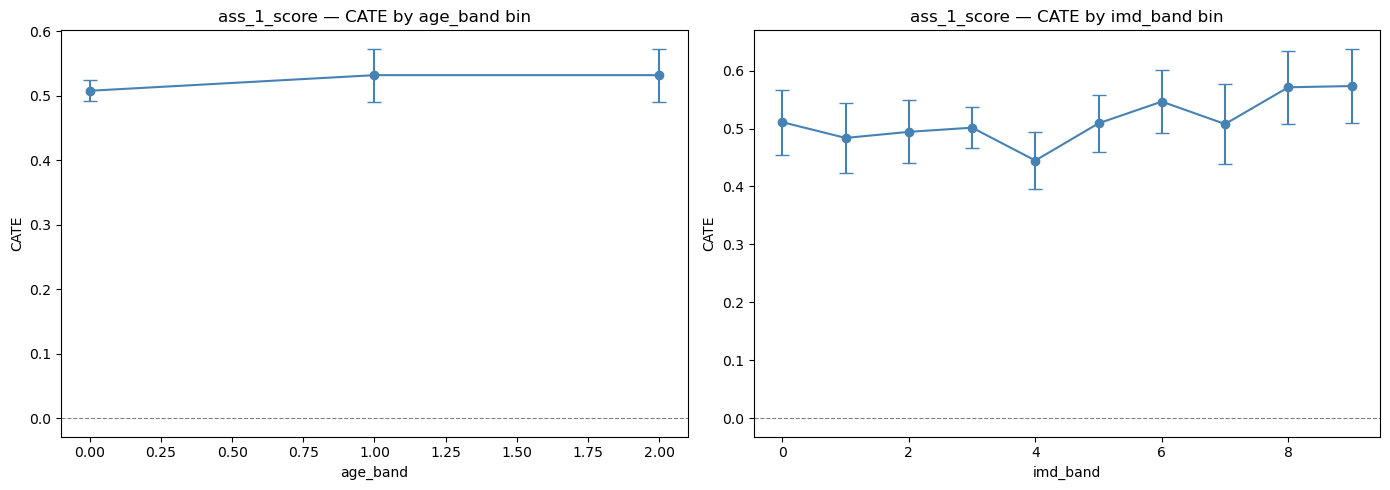

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\BBB\BBB_DAG2_CATE_ass_1_score.png


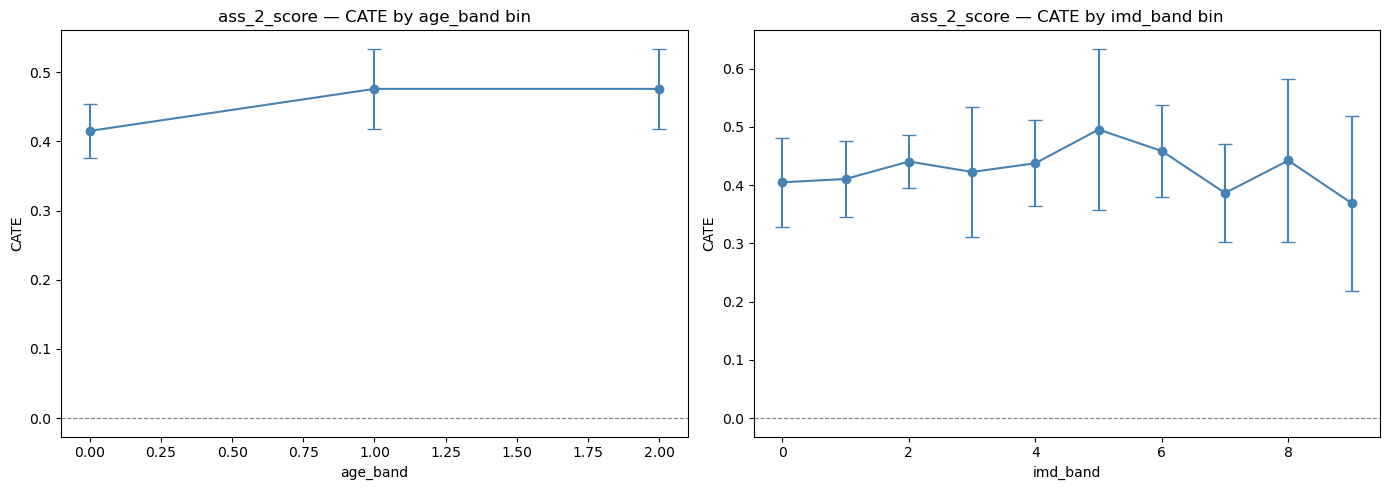

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\BBB\BBB_DAG2_CATE_ass_2_score.png


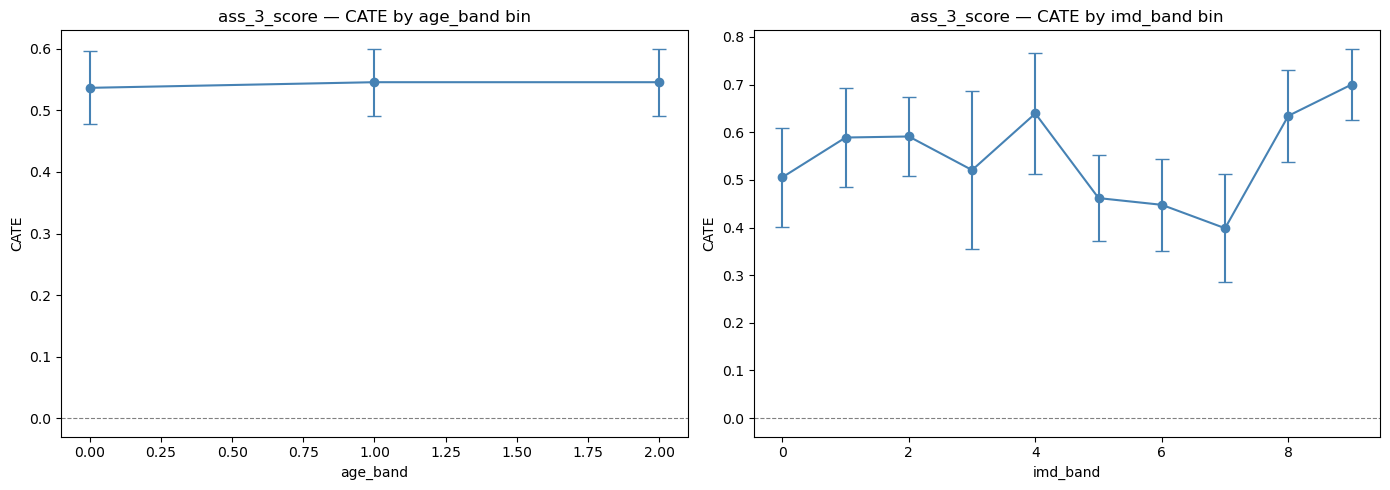

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\BBB\BBB_DAG2_CATE_ass_3_score.png


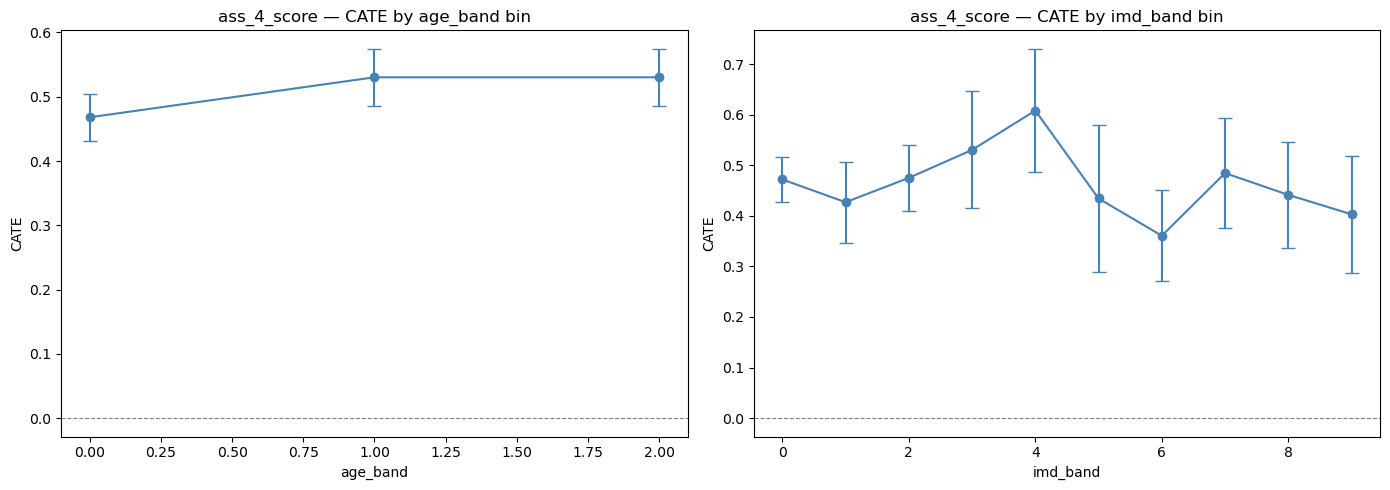

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\BBB\BBB_DAG2_CATE_ass_4_score.png


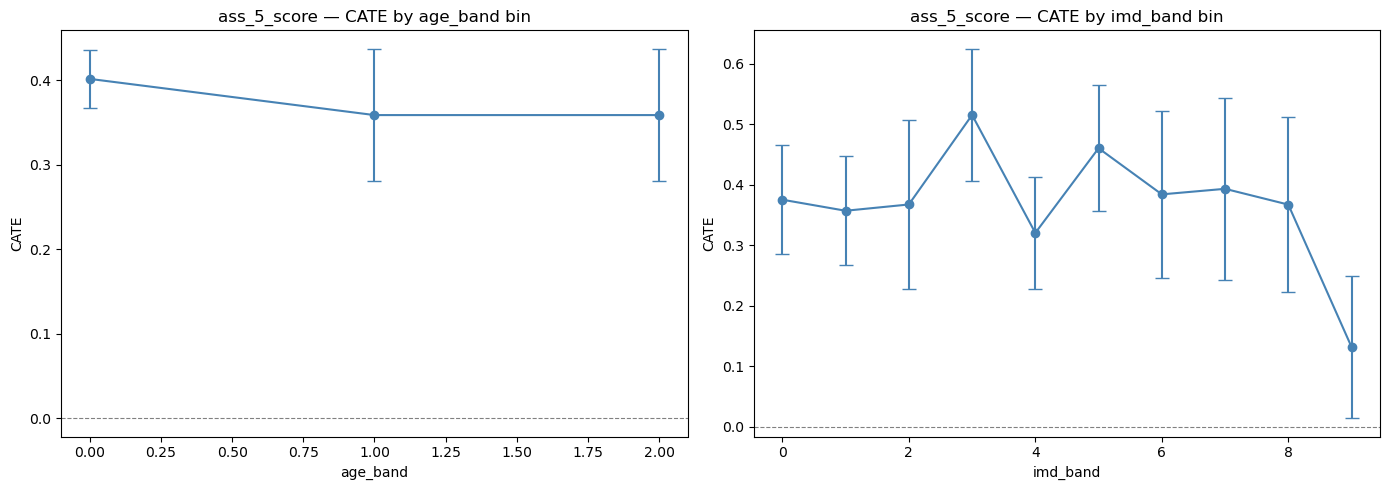

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\BBB\BBB_DAG2_CATE_ass_5_score.png


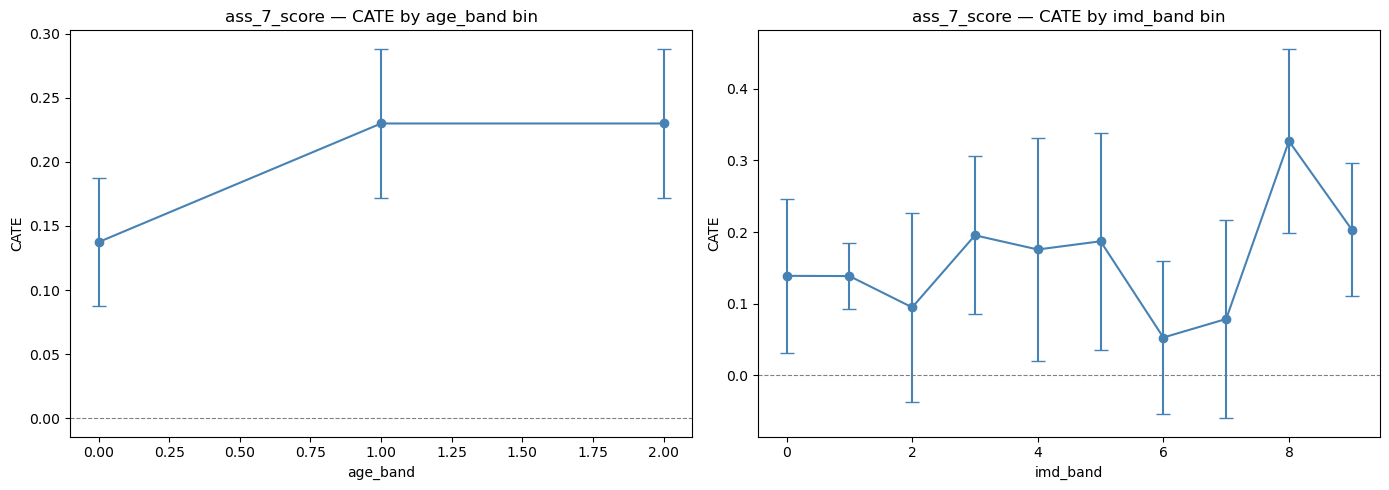

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\BBB\BBB_DAG2_CATE_ass_7_score.png


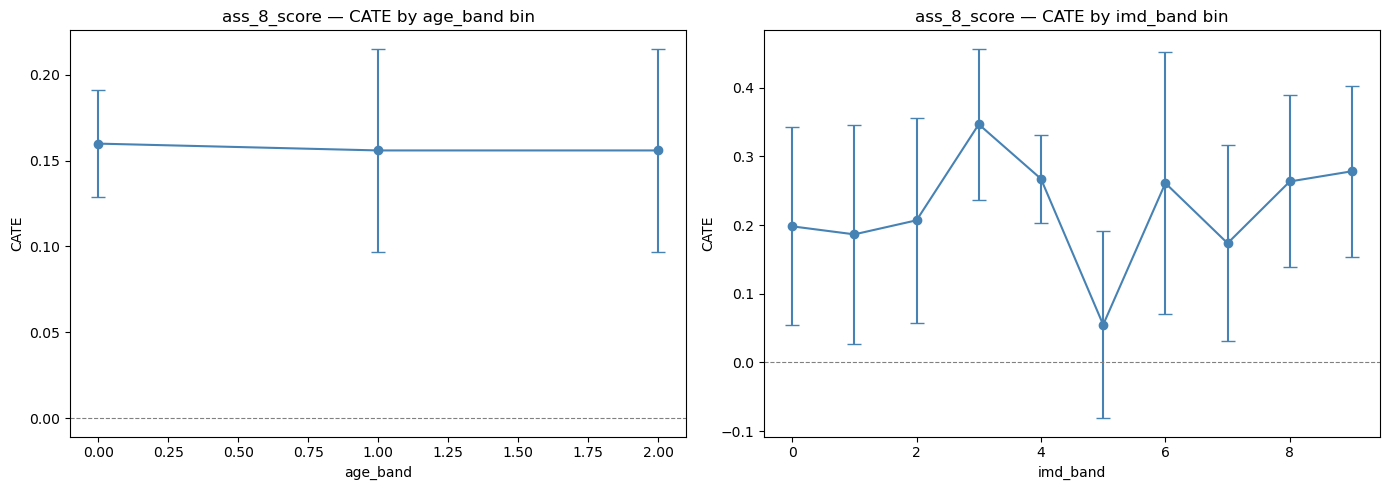

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\BBB\BBB_DAG2_CATE_ass_8_score.png


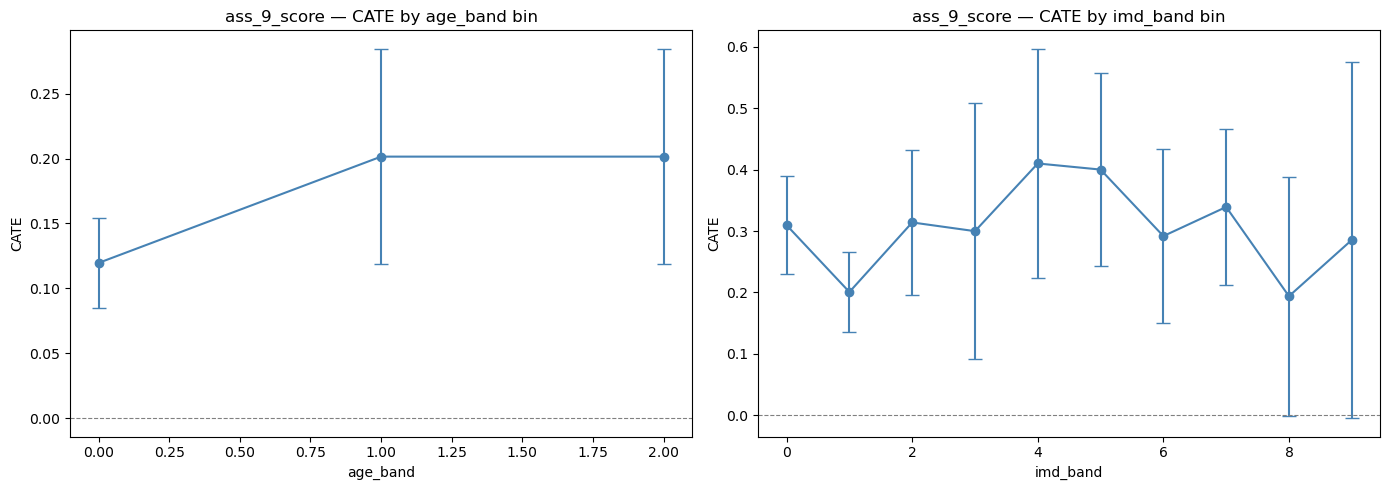

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\BBB\BBB_DAG2_CATE_ass_9_score.png


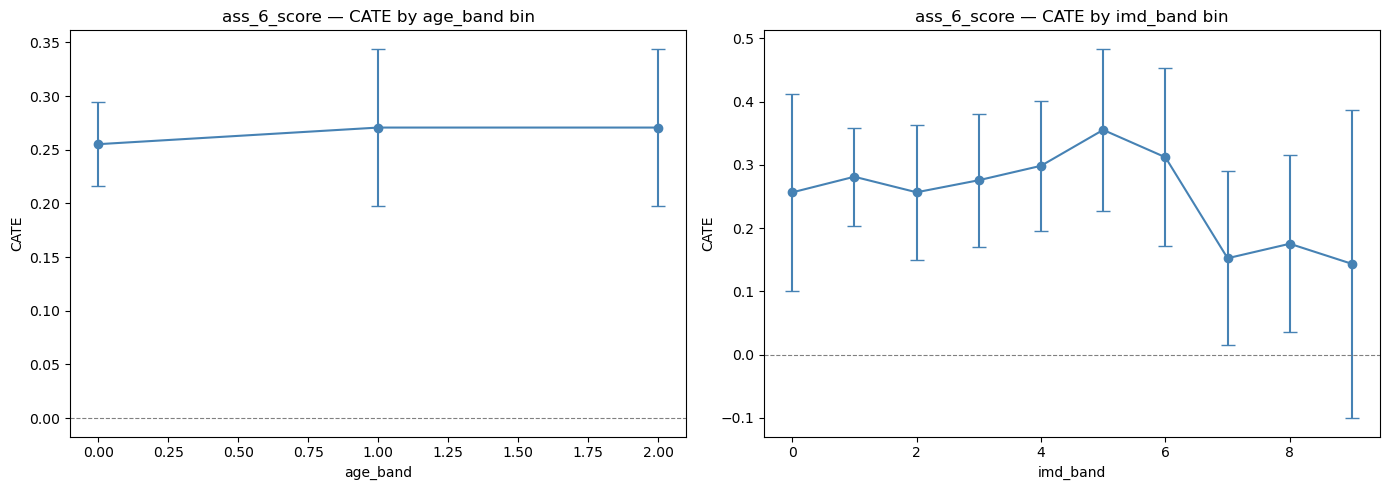

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\BBB\BBB_DAG2_CATE_ass_6_score.png


In [37]:
for treatment in dag2_treatments:
    adj_set = dag2_adjustment_sets[treatment]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, moderator in zip(axes, moderators):
        W_cols = [c for c in adj_set if c != moderator]

        X = df_dag2_cate[[moderator]].values
        T = df_dag2_cate[treatment].values
        Y = df_dag2_cate['final_result'].values
        W = df_dag2_cate[W_cols].values if len(W_cols) > 0 else None

        est = CausalForestDML(random_state=42)
        est.fit(Y, T, X=X, W=W)

        bin_values = sorted(df_dag2_cate[moderator].unique())
        X_bins = np.array(bin_values).reshape(-1, 1)

        point_estimates = est.effect(X_bins)
        lb, ub = est.effect_interval(X_bins, alpha=0.05)
        yerr = np.array([point_estimates - lb, ub - point_estimates])

        ax.errorbar(bin_values, point_estimates, yerr=yerr, fmt='o-', capsize=5, color='steelblue')
        ax.set_xlabel(moderator)
        ax.set_ylabel('CATE')
        ax.set_title(f'{treatment} — CATE by {moderator} bin')
        ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)

    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, f"BBB_DAG2_CATE_{treatment}.png")
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()
    print(f"Saved: {save_path}")

## 3-DAG-split ATE heatmap — all 22 treatments across DAG1/DAG2/DAG3

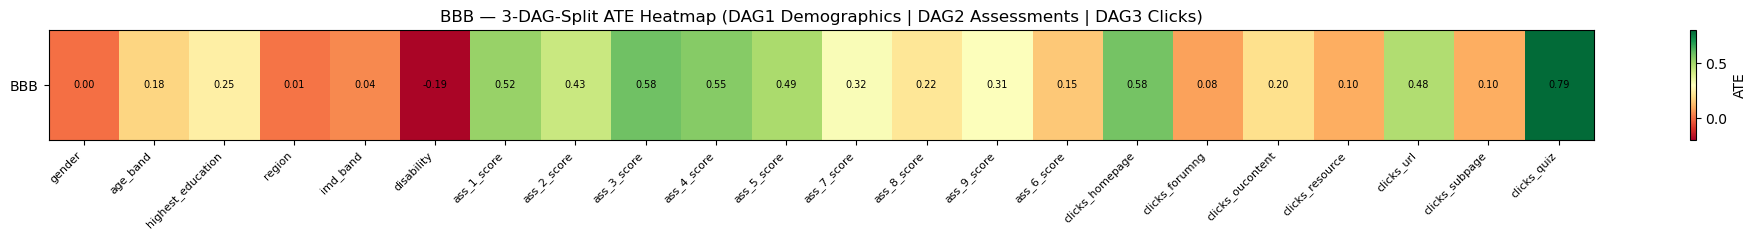

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\BBB\BBB_3DAGSplit_ATE_heatmap.png


In [40]:
all_split_results = pd.concat([dag1_results_df, dag2_results_df, dag3_results_df], ignore_index=True)

heatmap_data = all_split_results.set_index('treatment')[['ATE']].T

plt.figure(figsize=(20, 2.5))
plt.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto', vmin=-0.2, vmax=0.8)
plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns, rotation=45, ha='right', fontsize=8)
plt.yticks([0], ['BBB'])
plt.colorbar(label='ATE')

for i, val in enumerate(heatmap_data.values[0]):
    plt.text(i, 0, f'{val:.2f}', ha='center', va='center', fontsize=7)

plt.title('BBB — 3-DAG-Split ATE Heatmap (DAG1 Demographics | DAG2 Assessments | DAG3 Clicks)')
plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, "BBB_3DAGSplit_ATE_heatmap.png")
plt.savefig(save_path, dpi=150)
plt.show()
plt.close()
print(f"Saved: {save_path}")

## Three-panel DAG-with-ATE overlay — DAG1, DAG2, DAG3 side by side

C:\Users\Disha Sharma\AppData\Local\Temp\ipykernel_22564\1087841157.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.06, 1, 0.96])


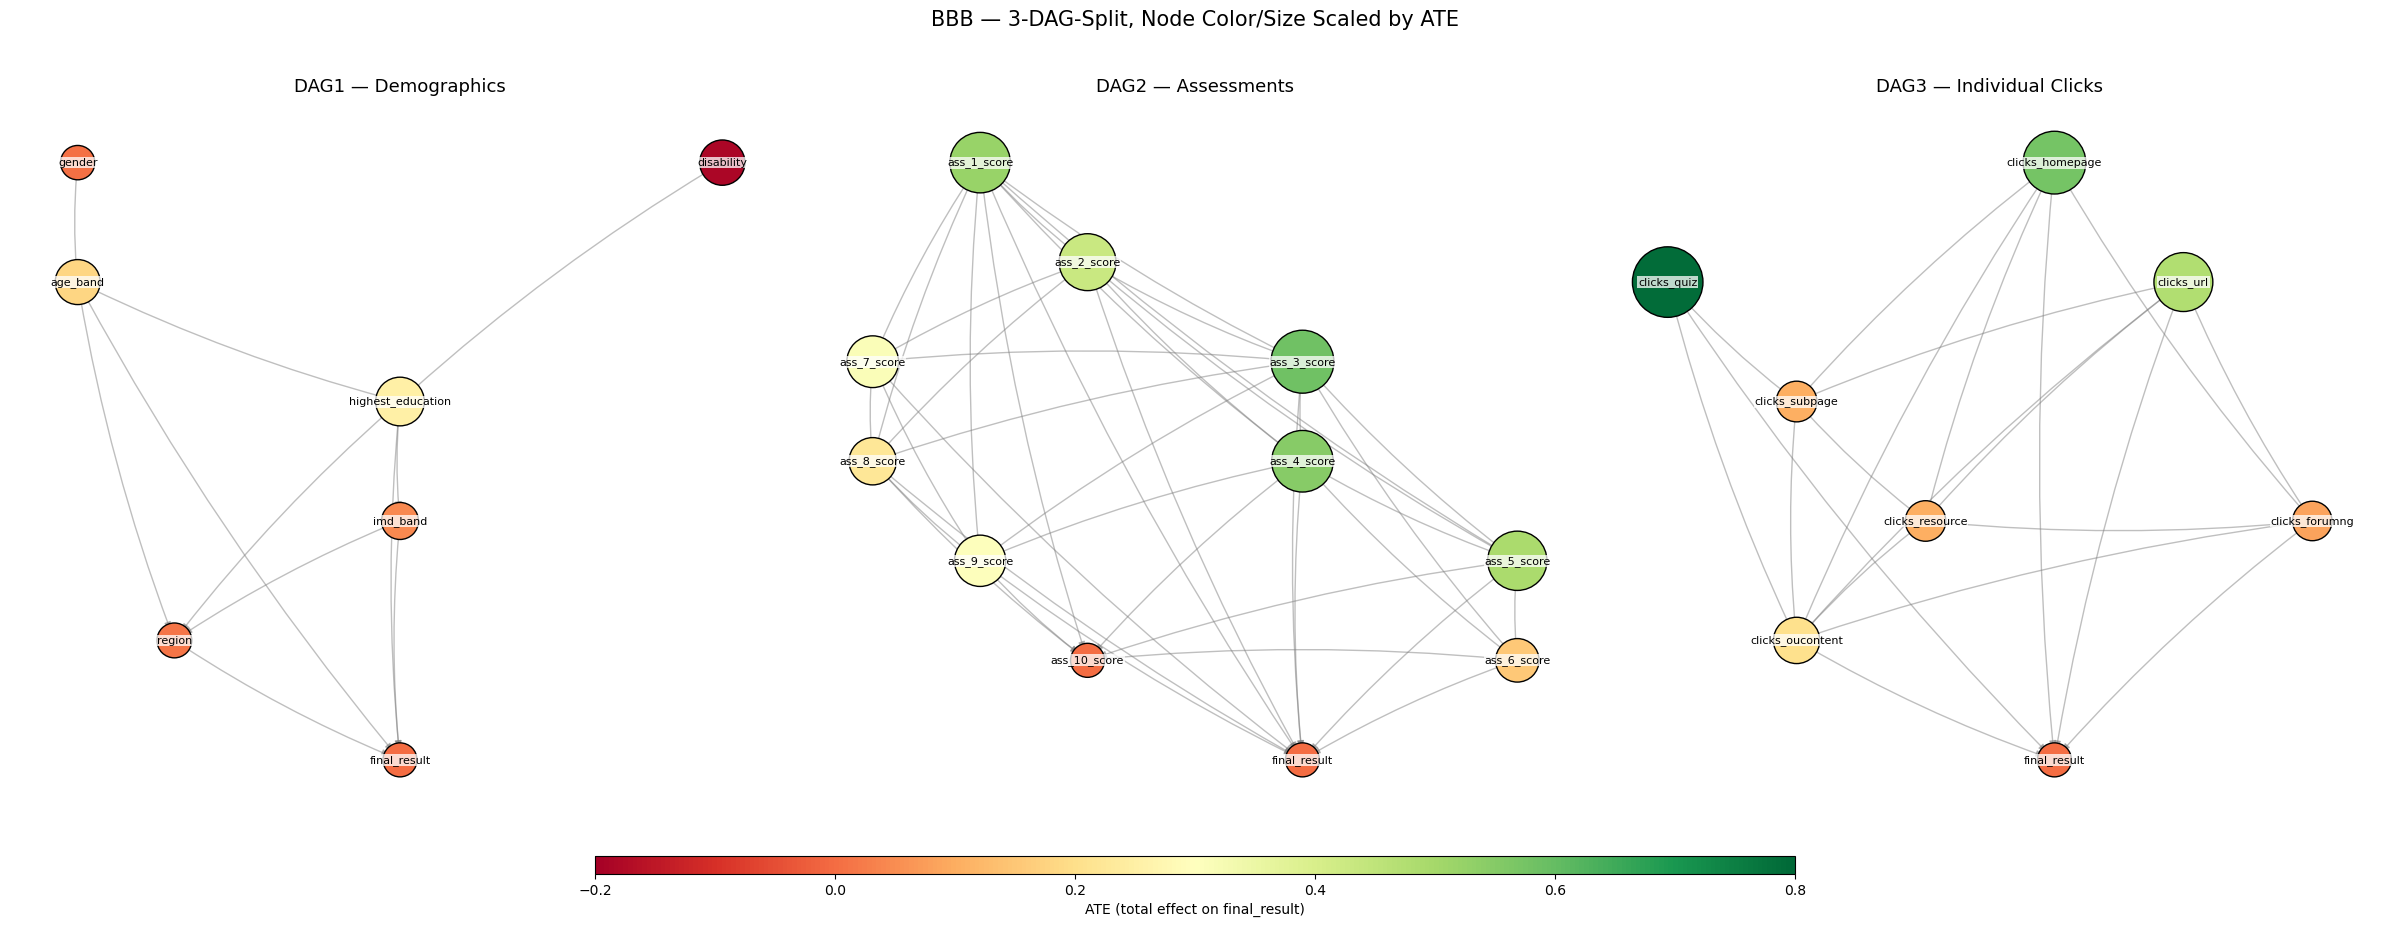

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\BBB\BBB_3DAGSplit_DAG_with_ATE.png


In [43]:
pos1 = {
    'gender': (1, 4), 'age_band': (1, 3), 'disability': (3, 4),
    'highest_education': (2, 2), 'num_of_prev_attempts': (3.5, 3),
    'imd_band': (2, 1), 'region': (1.3, 0), 'studied_credits': (3.5, 2),
    'final_result': (2, -1),
}

pos2 = {
    'ass_1_score': (1, 5), 'ass_11_score': (5, 5),
    'ass_2_score': (1.5, 4),
    'ass_3_score': (2.5, 3), 'ass_7_score': (0.5, 3),
    'ass_4_score': (2.5, 2), 'ass_8_score': (0.5, 2),
    'ass_5_score': (3.5, 1), 'ass_9_score': (1, 1),
    'ass_6_score': (3.5, 0), 'ass_10_score': (1.5, 0),
    'final_result': (2.5, -1),
}

pos3 = {
    'clicks_homepage': (2, 4), 'clicks_glossary': (5, 4), 'clicks_oucollaborate': (6, 4),
    'clicks_ouelluminate': (7, 4), 'clicks_sharedsubpage': (8, 4),
    'clicks_quiz': (0.5, 3), 'clicks_url': (2.5, 3),
    'clicks_subpage': (1, 2),
    'clicks_resource': (1.5, 1), 'clicks_forumng': (3, 1),
    'clicks_oucontent': (1, 0),
    'final_result': (2, -1),
}

fig, axes = plt.subplots(1, 3, figsize=(24, 9))
ate_lookup_all = all_split_results.set_index('treatment')['ATE'].to_dict()
titles = ['DAG1 — Demographics', 'DAG2 — Assessments', 'DAG3 — Individual Clicks']

for ax, Gx, posx, title in zip(axes, [G1, G2, G3], [pos1, pos2, pos3], titles):
    missing = [n for n in Gx.nodes() if n not in posx]
    if missing:
        print(f"WARNING — missing pos in {title}:", missing)

    node_colors, node_sizes = [], []
    for node in Gx.nodes():
        ate_val = ate_lookup_all.get(node, 0)
        node_colors.append(ate_val)
        node_sizes.append(600 + abs(ate_val) * 2500)

    nx.draw_networkx_edges(Gx, posx, ax=ax, edge_color='gray', arrows=True, arrowsize=10,
                            alpha=0.5, connectionstyle='arc3,rad=0.05')
    nc = nx.draw_networkx_nodes(Gx, posx, ax=ax, node_color=node_colors, node_size=node_sizes,
                                 cmap='RdYlGn', vmin=-0.2, vmax=0.8, edgecolors='black')
    nx.draw_networkx_labels(Gx, posx, ax=ax, font_size=8,
                             bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=0.4))
    ax.set_title(title, fontsize=13)
    ax.axis('off')

cbar_ax = fig.add_axes([0.25, 0.02, 0.5, 0.02])
plt.colorbar(nc, cax=cbar_ax, orientation='horizontal', label='ATE (total effect on final_result)')

plt.suptitle('BBB — 3-DAG-Split, Node Color/Size Scaled by ATE', fontsize=15)
plt.tight_layout(rect=[0, 0.06, 1, 0.96])
save_path = os.path.join(OUTPUT_DIR, "BBB_3DAGSplit_DAG_with_ATE.png")
plt.savefig(save_path, dpi=150)
plt.show()
plt.close()
print(f"Saved: {save_path}")